### Important Libraries

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Load Dataset

In [49]:
df = pd.read_csv("smart_healthcare_dataset.csv")

df.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


### Data Stats

In [50]:
print(df.shape)
df.describe()

(5000, 16)


,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,48.805600,24.967800,1.005800,0.507600,0.501400,134.445400,224.616400,134.497400,0.515200,0.504000,0.497400,0.299800,0.349200,0.248600,100.0
std,17.906991,4.960379,0.815291,0.499992,0.500048,26.191438,43.129773,37.437028,0.499819,0.500034,0.500043,0.458216,0.476765,0.432245,0.0
min,18.000000,15.000000,0.000000,0.000000,0.000000,90.000000,150.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,34.000000,21.500000,0.000000,0.000000,0.000000,111.000000,187.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
50%,49.000000,24.900000,1.000000,1.000000,1.000000,134.000000,226.000000,134.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.0
75%,64.000000,28.400000,2.000000,1.000000,1.000000,157.000000,262.000000,167.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,100.0
max,79.000000,42.600000,2.000000,1.000000,1.000000,179.000000,299.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.0


### Check Null vlaues

In [51]:
df.isnull().sum()
df.head(10)

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0
5,25,Female,26.0,1,0,0,164,260,187,1,0,0,0,0,0,100.0
6,78,Female,24.6,0,1,1,121,207,98,1,1,0,1,1,1,100.0
7,38,Female,22.1,2,1,0,103,227,171,0,0,1,0,0,0,100.0
8,56,Female,22.6,0,0,1,177,197,100,1,0,1,0,0,0,100.0
9,75,Female,28.5,1,1,0,106,205,144,0,0,0,1,1,1,100.0


In [52]:
print(df.duplicated().sum())

0


### Kurtosis Analysis

In [53]:
import pandas as pd

# Select only the required columns
cols = ["age", "bmi", "blood_pressure", "cholesterol", "glucose"]

# Calculate kurtosis
kurtosis = df[cols].kurt()

print(kurtosis)

age              -1.182815
bmi              -0.224060
blood_pressure   -1.231463
cholesterol      -1.191665
glucose          -1.178927
dtype: float64


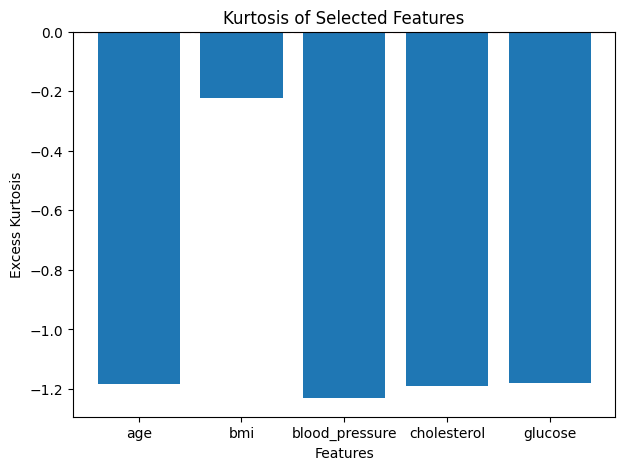

In [54]:
import matplotlib.pyplot as plt

cols = ["age", "bmi", "blood_pressure", "cholesterol", "glucose"]

kurtosis = df[cols].kurt()

plt.figure(figsize=(7,5))
plt.bar(kurtosis.index, kurtosis.values)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Features")
plt.ylabel("Excess Kurtosis")
plt.title("Kurtosis of Selected Features")
plt.show()

### skewness

In [55]:
cols = ["age", "bmi", "blood_pressure", "cholesterol", "glucose"]

print(df[cols].skew())

age              -0.013819
bmi               0.147533
blood_pressure    0.016648
cholesterol      -0.019761
glucose           0.008217
dtype: float64


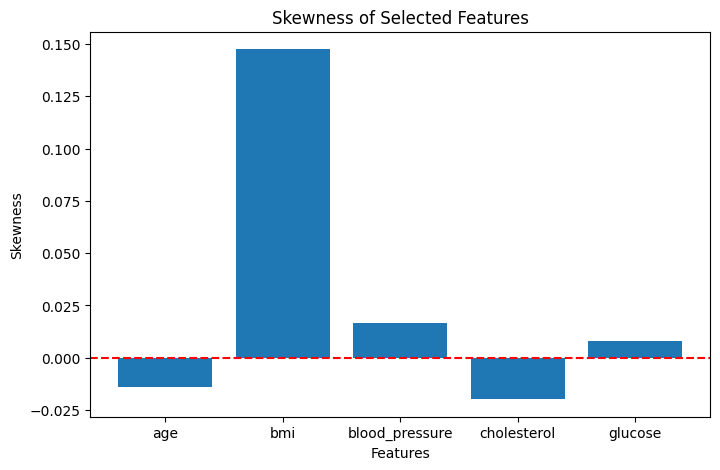

In [56]:
import matplotlib.pyplot as plt

skew = df[["age","bmi","blood_pressure","cholesterol","glucose"]].skew()

plt.figure(figsize=(8,5))
plt.bar(skew.index, skew.values)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Features")
plt.ylabel("Skewness")
plt.title("Skewness of Selected Features")
plt.show()

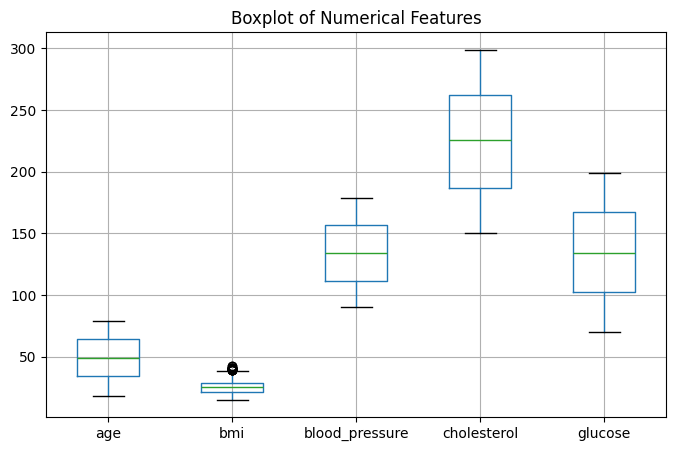

In [57]:
import matplotlib.pyplot as plt

cols = ["age", "bmi", "blood_pressure", "cholesterol", "glucose"]

df[cols].boxplot(figsize=(8,5))
plt.title("Boxplot of Numerical Features")
plt.show()

### Histogram

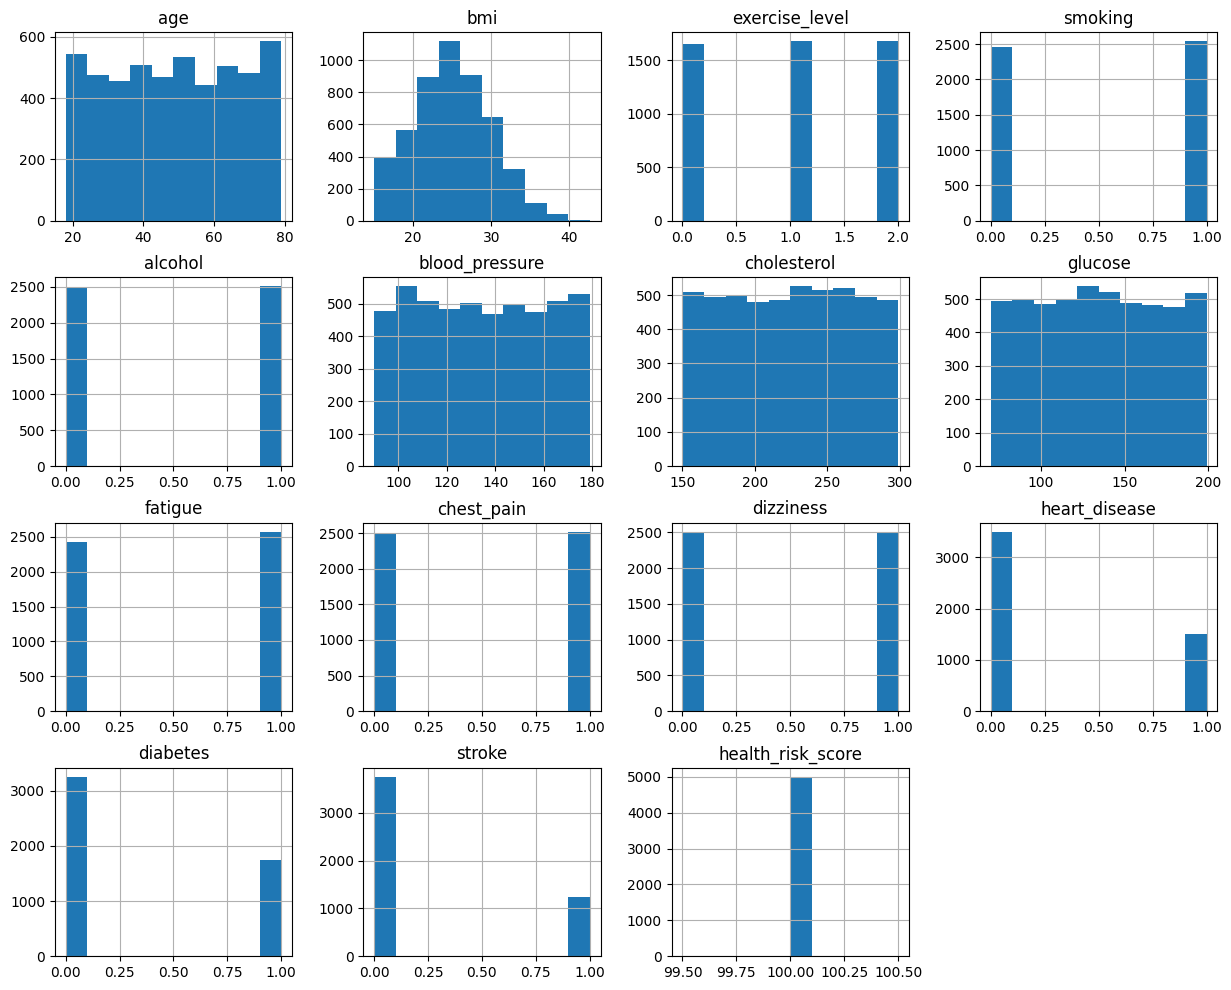

In [58]:
df.hist(figsize=(15,12))
plt.show()

### Feature Engineering

In [59]:
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [60]:
df["cardio_risk"] = (
    (df["blood_pressure"] >= 140) |
    (df["cholesterol"] >= 240)
).astype(int)

df["metabolic_syndrome"] = (
    (df["bmi"] >= 30) &
    (df["blood_pressure"] >= 140) &
    (df["glucose"] >= 126)
).astype(int)


df.drop("health_risk_score", axis=1, inplace=True)
#df.drop("gender", axis=1, inplace=True)
#df.drop("fatigue", axis=1, inplace=True )      

### Train-Test split


In [61]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature scaling

In [63]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression

In [64]:
# Model training
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


### Model evaluation || Classification Metrics 

In [65]:
print("Logistic Regression")

print("Training Accuracy :", lr.score(X_train, y_train)) # Training accuracy

print("Testing Accuracy :", lr.score(X_test, y_test)) # Testing accuracy

print("Accuracy :", accuracy_score(y_test, y_pred_lr)) # accuracy

print(confusion_matrix(y_test, y_pred_lr)) # confusion matrix

print(classification_report(y_test, y_pred_lr)) # precision , recall , f1-score , support

Logistic Regression
Training Accuracy : 0.989
Testing Accuracy : 0.989
Accuracy : 0.989
[[697   3]
 [  8 292]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       700
           1       0.99      0.97      0.98       300

    accuracy                           0.99      1000
   macro avg       0.99      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000



### Actual vs Predicted

In [66]:
comparison_lr = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

print(comparison_lr.head(10))

   Actual  Predicted
0       1          1
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       1          1


### Model using Decesion Tress

In [67]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [68]:
print("Decision Tree")

print("Training Accuracy :", dt.score(X_train, y_train))  # Training accuracy

print("Testing Accuracy :", dt.score(X_test, y_test)) # Testing accuracy

print("Accuracy :", accuracy_score(y_test, y_pred_dt))  # accuracy

print(confusion_matrix(y_test, y_pred_dt)) # confusion matrix

print(classification_report(y_test, y_pred_dt)) # precision , recall , f1-score , support

Decision Tree
Training Accuracy : 1.0
Testing Accuracy : 0.972
Accuracy : 0.972
[[687  13]
 [ 15 285]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       700
           1       0.96      0.95      0.95       300

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



### Actual vs Predicted

In [69]:
comparison_dt = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

print(comparison_dt.head(10))

   Actual  Predicted
0       1          1
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       1          1


### Model using Suport Vector Machine (SVM)

In [70]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)



### Model Evaluation 

In [71]:
print("Support Vector Machine")

print("Training Accuracy :", svm.score(X_train, y_train))

print("Testing Accuracy :", svm.score(X_test, y_test))

print("Accuracy :", accuracy_score(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

Support Vector Machine
Training Accuracy : 0.98075
Testing Accuracy : 0.966
Accuracy : 0.966
[[685  15]
 [ 19 281]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       700
           1       0.95      0.94      0.94       300

    accuracy                           0.97      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



### Actual vs Predicted

In [72]:
comparison_svm = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_svm
})

print(comparison_svm.head(10))

   Actual  Predicted
0       1          1
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       1          1


### Feature selection

In [73]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
# Independent and Target variables
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]
    
    # Random Forest Model
rf = RandomForestClassifier(random_state=42)
    
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [77]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

               Feature  Importance
0                  age    0.325662
12            diabetes    0.290676
13              stroke    0.237284
2                  bmi    0.063274
7          cholesterol    0.016099
6       blood_pressure    0.015324
8              glucose    0.015263
10          chest_pain    0.008148
4              smoking    0.007214
3       exercise_level    0.004978
5              alcohol    0.003222
1               gender    0.003128
9              fatigue    0.002699
14         cardio_risk    0.002447
11           dizziness    0.002398
15  metabolic_syndrome    0.002186


In [78]:
selected_features = feature_importance[
    feature_importance["Importance"] > 0.02
]

print(selected_features)

     Feature  Importance
0        age    0.325662
12  diabetes    0.290676
13    stroke    0.237284
2        bmi    0.063274


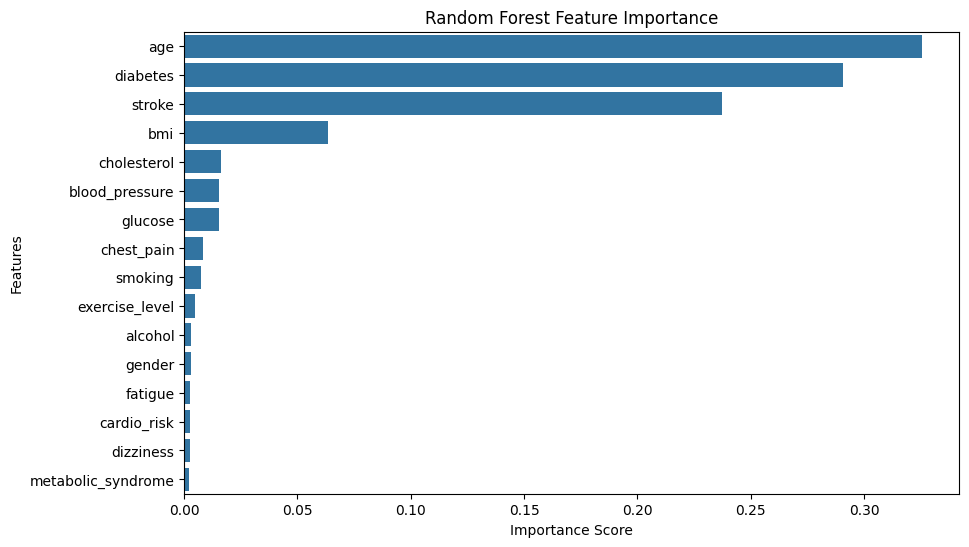

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [80]:
import pickle

# Train your model
dt.fit(X_train, y_train)

# Save the model again
pickle.dump(lr, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [81]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values("Importance", ascending=False))

               Feature  Importance
0                  age    0.450911
13              stroke    0.336791
2                  bmi    0.046225
15  metabolic_syndrome    0.034473
4              smoking    0.029492
10          chest_pain    0.026915
14         cardio_risk    0.017010
6       blood_pressure    0.010201
7          cholesterol    0.009383
12            diabetes    0.008449
11           dizziness    0.007664
3       exercise_level    0.006079
5              alcohol    0.005666
8              glucose    0.005448
9              fatigue    0.003596
1               gender    0.001697


In [82]:
corr = df.corr(numeric_only=True)

print(corr["heart_disease"].sort_values(ascending=False))

heart_disease         1.000000
diabetes              0.857576
stroke                0.842684
age                   0.776642
bmi                   0.133455
metabolic_syndrome    0.043868
blood_pressure        0.041059
chest_pain            0.038855
cardio_risk           0.028277
smoking               0.027161
cholesterol           0.018736
alcohol               0.007335
fatigue               0.004118
dizziness             0.001220
glucose              -0.009114
gender               -0.009343
exercise_level       -0.010010
Name: heart_disease, dtype: float64


In [85]:
df = pd.read_csv("smart_healthcare_dataset.csv")

df.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


### Confusion matrix on testing


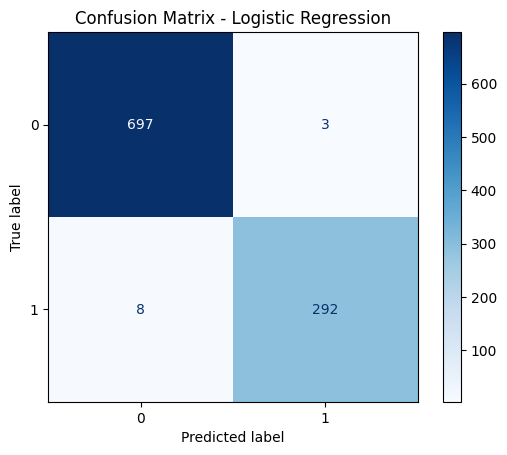

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()